#  Ex1 Linear Regression: synthetic data


In [1]:
import torch
import numpy as np
from matplotlib import pyplot as plt
import torch.nn as nn
import torch.optim as opt

In [2]:
N= 30

In [3]:
#rand (-5,5)
X = np.random.rand(N)*10-5

In [4]:
y = 0.5 *X +(np.random.randn(N) - 1)

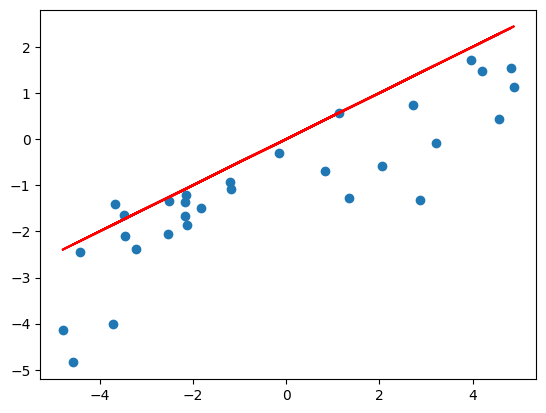

In [5]:
plt.scatter(X,y)
plt.plot(X,0.5 *X ,color='red')
plt.show()

## Building the model ##

In [6]:
model = nn.Linear(1,1)
criterion = nn.MSELoss()
optimizer = opt.SGD(model.parameters(),lr=0.01)

## reshape X,y to match samples and convert to tensors

In [7]:
X = X.reshape(N,1)
y = y.reshape(N,1)
if torch.cuda.is_available():
    print("CUDA")
    inputs = torch.from_numpy(X.astype(np.float32)).cuda()
    targets = torch.from_numpy(y.astype(np.float32)).cuda()

    model = model.cuda()
    criterion = criterion.cuda()
else:
    print("CPU")
    inputs = torch.from_numpy(X.astype(np.float32))
    targets = torch.from_numpy(y.astype(np.float32))   

CUDA


## training loop

In [8]:
EPOCHS = 75

losses = []
for epoch in range(EPOCHS):
    model.zero_grad()

    predictions = model(inputs)
    loss = criterion(targets,predictions)
    losses.append(loss.item())
    loss.backward()
    optimizer.step()
    print(f'epoch {epoch+1}/{EPOCHS}: Loss {loss.item():.4f}')

epoch 1/75: Loss 5.4372
epoch 2/75: Loss 4.5460
epoch 3/75: Loss 3.9415
epoch 4/75: Loss 3.5223
epoch 5/75: Loss 3.2232
epoch 6/75: Loss 3.0024
epoch 7/75: Loss 2.8330
epoch 8/75: Loss 2.6976
epoch 9/75: Loss 2.5852
epoch 10/75: Loss 2.4885
epoch 11/75: Loss 2.4028
epoch 12/75: Loss 2.3250
epoch 13/75: Loss 2.2533
epoch 14/75: Loss 2.1864
epoch 15/75: Loss 2.1232
epoch 16/75: Loss 2.0633
epoch 17/75: Loss 2.0062
epoch 18/75: Loss 1.9517
epoch 19/75: Loss 1.8995
epoch 20/75: Loss 1.8494
epoch 21/75: Loss 1.8014
epoch 22/75: Loss 1.7553
epoch 23/75: Loss 1.7110
epoch 24/75: Loss 1.6685
epoch 25/75: Loss 1.6276
epoch 26/75: Loss 1.5884
epoch 27/75: Loss 1.5506
epoch 28/75: Loss 1.5144
epoch 29/75: Loss 1.4795
epoch 30/75: Loss 1.4460
epoch 31/75: Loss 1.4138
epoch 32/75: Loss 1.3828
epoch 33/75: Loss 1.3531
epoch 34/75: Loss 1.3245
epoch 35/75: Loss 1.2970
epoch 36/75: Loss 1.2706
epoch 37/75: Loss 1.2452
epoch 38/75: Loss 1.2208
epoch 39/75: Loss 1.1973
epoch 40/75: Loss 1.1748
epoch 41/

## predict

In [14]:
predictions = model(inputs)

In [15]:
predictions1 = predictions.cpu().detach().numpy()

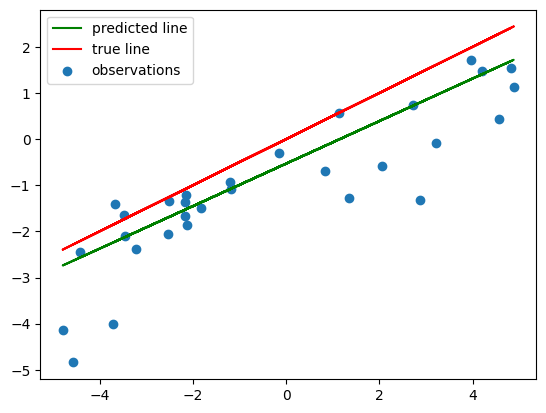

In [16]:
plt.plot(X,predictions1,color='green',label="predicted line")
plt.plot(X, 0.5 *X,color='red',label='true line')
plt.scatter(X,y,label='observations')
plt.legend(loc="upper left")

another option to predict is using torch.no_grad() to avoid calling detach

In [20]:
with torch.no_grad():
    out = model(inputs)
    print(out.cpu().numpy())

[[-2.633944  ]
 [ 0.08698424]
 [-2.2189455 ]
 [-2.5727928 ]
 [ 0.41988143]
 [ 0.94785637]
 [-2.2412775 ]
 [ 0.7203501 ]
 [-2.7389076 ]
 [ 1.7173102 ]
 [ 0.79082704]
 [-1.6988095 ]
 [-1.3678904 ]
 [-1.5358124 ]
 [-1.0910207 ]
 [-2.1318944 ]
 [-1.5243938 ]
 [-0.00513844]
 [ 1.569177  ]
 [-0.14821349]
 [-1.0729591 ]
 [-1.6875114 ]
 [-0.5990623 ]
 [-2.1220603 ]
 [-2.017305  ]
 [ 1.6898063 ]
 [-1.5063759 ]
 [-1.5313861 ]
 [ 1.4010639 ]
 [ 1.2928369 ]]


## let's plot the loss

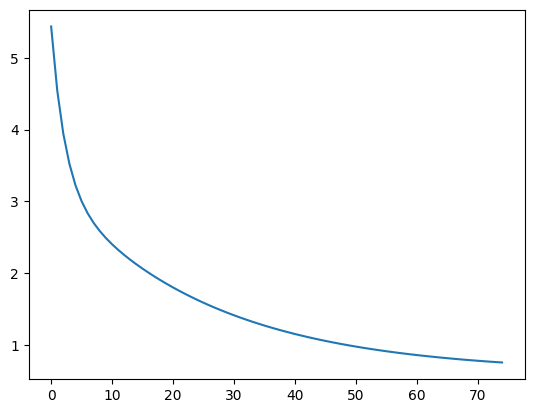

In [12]:
plt.plot([i for i in range(len(losses))],losses)


as we can see we should set EPOCHS to 75 beyond that we don't really learn much

## let's extract our weights and bias

In [23]:
w = model.weight.cpu().data.numpy()
b = model.bias.cpu().data.numpy()
print(f'weight {w}X+{b}')

weight [[0.46079618]]X+[-0.5313809]
